In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [ ]:
# Make sure filenames match exactly
df_temp = pd.read_csv("/content/electricity_cleaned.txt")      # main energy file
metadata = pd.read_csv("/content/metadata.txt")

# Reshape electricity data from wide to long format
electricity = df_temp.melt(
    id_vars=['timestamp'],
    var_name='building_id',
    value_name='meter_reading'
)

print("Electricity Data Shape:", electricity.shape)
print("Metadata Shape:", metadata.shape)

Electricity Data Shape: (27684432, 3)
Metadata Shape: (1636, 32)


In [ ]:
#2️ Filter Only Office Buildings
# ==============================
office_buildings = metadata[metadata['primaryspaceusage'] == 'Office']

electricity = electricity[electricity['building_id'].isin(office_buildings['building_id'])]

print("Filtered Office Data Shape:", electricity.shape)

Filtered Office Data Shape: (5193024, 3)


In [ ]:
# 3️ Feature Engineering
# ==============================
electricity['timestamp'] = pd.to_datetime(electricity['timestamp'])

electricity['day_of_week'] = electricity['timestamp'].dt.dayofweek
electricity['hour'] = electricity['timestamp'].dt.hour

# Weekend flag (1 = Sat/Sun, 0 = Weekday)
electricity['is_weekend'] = electricity['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [ ]:
# 4️ Create Usage Profile (Per Building)
# ==============================
usage_profile = electricity.groupby('building_id').agg({
    'meter_reading': 'mean',
    'is_weekend': 'mean'
}).reset_index()

usage_profile.rename(columns={'meter_reading':'avg_usage'}, inplace=True)

In [ ]:
# 5️ Apply K-Means Clustering
# ==============================
scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    usage_profile[['avg_usage','is_weekend']]
)

kmeans = KMeans(n_clusters=3, random_state=42)
usage_profile['cluster'] = kmeans.fit_predict(scaled_features)

print("Cluster Distribution:")
print(usage_profile['cluster'].value_counts())

Cluster Distribution:
cluster
2    267
0     25
1      4
Name: count, dtype: int64


In [ ]:
# 6️ Train Regression Model per Cluster
# ==============================
cluster_models = {}

for c in usage_profile['cluster'].unique():
    buildings = usage_profile[usage_profile['cluster']==c]['building_id']

    cluster_data = electricity[electricity['building_id'].isin(buildings)]

    # Drop rows where 'meter_reading' is NaN
    cluster_data = cluster_data.dropna(subset=['meter_reading'])

    X = cluster_data[['hour','is_weekend']]
    y = cluster_data['meter_reading']

    model = LinearRegression()
    model.fit(X,y)

    cluster_models[c] = model

In [ ]:
# 7️ Predict & Calculate Savings
# ==============================
electricity['predicted'] = 0.0 # Initialize as float to avoid FutureWaring

for c in cluster_models:
    buildings = usage_profile[usage_profile['cluster']==c]['building_id']
    mask = electricity['building_id'].isin(buildings)

    electricity.loc[mask,'predicted'] = cluster_models[c].predict(
        electricity.loc[mask,['hour','is_weekend']]
    )

electricity['savings'] = electricity['meter_reading'] - electricity['predicted']

weekend_savings = electricity[electricity['is_weekend']==1]['savings'].sum()

print("\nEstimated Total Weekend Savings (unrounded):", weekend_savings)


Estimated Total Weekend Savings (unrounded): 9.612995199859142e-08


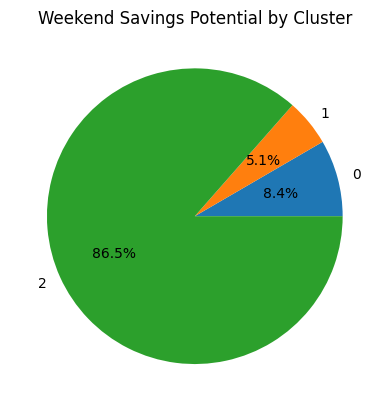

In [ ]:
# ==============================
# 8️ Merge Cluster Info
# ==============================
merged = electricity.merge(
    usage_profile[['building_id','cluster']],
    on='building_id'
)

cluster_savings = merged[merged['is_weekend']==1].groupby(
    'cluster'
)['savings'].sum()

plt.figure()
plt.pie(cluster_savings, labels=cluster_savings.index, autopct='%1.1f%%')
plt.title("Weekend Savings Potential by Cluster")
plt.show()

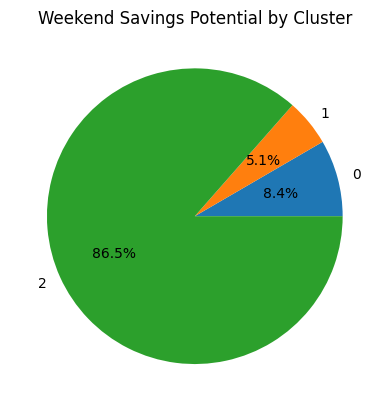

In [ ]:
# 9️ Pie Chart – Savings by Cluster
# ==============================
cluster_savings = merged[merged['is_weekend']==1].groupby(
    'cluster'
)['savings'].sum()

plt.figure()
plt.pie(cluster_savings, labels=cluster_savings.index, autopct='%1.1f%%')
plt.title("Weekend Savings Potential by Cluster")
plt.show()